# Exploratory Data Analysis of BRFSS 2015 Diabetes Health Indicators Dataset

This notebook performs exploratory data analysis on two BRFSS 2015 diabetes datasets:

1. Multiclass dataset: diabetes_012_health_indicators_BRFSS2015.csv  
2. Binary dataset: diabetes_binary_health_indicators_BRFSS2015.csv  

The purpose of this EDA is to understand dataset structure, target imbalance, feature distributions, and class-level differences before applying machine learning models.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [2]:
df_multi = pd.read_csv("/content/drive/MyDrive/MRP/codes/EDA/diabetes_012_health_indicators_BRFSS2015.csv")
df_binary = pd.read_csv("/content/drive/MyDrive/MRP/codes/EDA/diabetes_binary_health_indicators_BRFSS2015.csv")

In [ ]:
df_multi.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [ ]:
df_binary.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


#Dataset Overview

In [ ]:
print("Multiclass dataset shape:", df_multi.shape)
print("Binary dataset shape:", df_binary.shape)

Multiclass dataset shape: (253680, 22)
Binary dataset shape: (253680, 22)


In [ ]:
print("Multiclass columns:")
print(df_multi.columns.tolist())

print("\nBinary columns:")
print(df_binary.columns.tolist())

Multiclass columns:
['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Binary columns:
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [ ]:
df_multi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [ ]:
df_binary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

# Check Missing Values and Duplicates

In [ ]:
df_multi.isnull().sum()

,0
Diabetes_012,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [ ]:
df_binary.isnull().sum()

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [ ]:
print("Duplicate rows in multiclass dataset:", df_multi.duplicated().sum())
print("Duplicate rows in binary dataset:", df_binary.duplicated().sum())

Duplicate rows in multiclass dataset: 23899
Duplicate rows in binary dataset: 24206


In [ ]:
df_multi.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


In [ ]:
df_binary.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


# Target Variable Distribution

## Multiclass target distribution

In [ ]:
multi_counts = df_multi['Diabetes_012'].value_counts().sort_index()
multi_percent = df_multi['Diabetes_012'].value_counts(normalize=True).sort_index() * 100

target_summary_multi = pd.DataFrame({
    'Count': multi_counts,
    'Percentage': multi_percent
})

target_summary_multi

,Count,Percentage
Diabetes_012,,
0.0,213703,84.241170
1.0,4631,1.825528
2.0,35346,13.933302


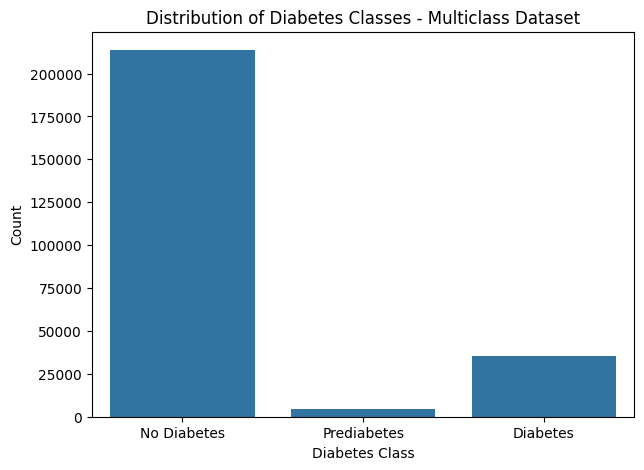

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df_multi, x='Diabetes_012')
plt.title("Distribution of Diabetes Classes - Multiclass Dataset")
plt.xlabel("Diabetes Class")
plt.ylabel("Count")
plt.xticks([0, 1, 2], ["No Diabetes", "Prediabetes", "Diabetes"])
plt.savefig('/content/drive/MyDrive/MRP/codes/EDA/Multiclass_Target_Distribution.png', bbox_inches='tight')
plt.show()

##Binary target distribution

In [ ]:
binary_counts = df_binary['Diabetes_binary'].value_counts().sort_index()
binary_percent = df_binary['Diabetes_binary'].value_counts(normalize=True).sort_index() * 100

target_summary_binary = pd.DataFrame({
    'Count': binary_counts,
    'Percentage': binary_percent
})

target_summary_binary

,Count,Percentage
Diabetes_binary,,
0.0,218334,86.066698
1.0,35346,13.933302


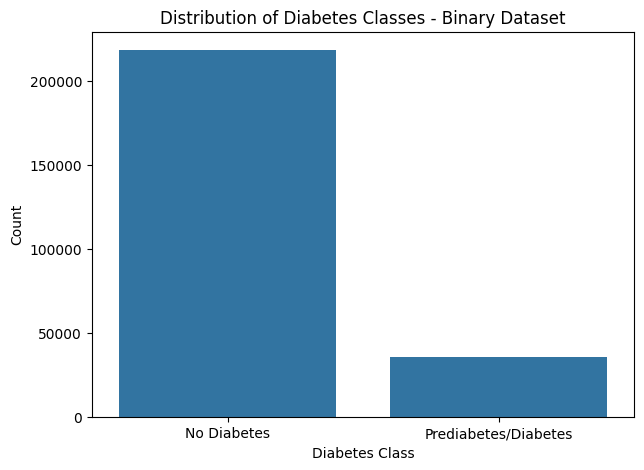

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df_binary, x='Diabetes_binary')
plt.title("Distribution of Diabetes Classes - Binary Dataset")
plt.xlabel("Diabetes Class")
plt.ylabel("Count")
plt.xticks([0, 1], ["No Diabetes", "Prediabetes/Diabetes"])
plt.savefig('/content/drive/MyDrive/MRP/codes/EDA/Binaryclass_Target_Distribution.png', bbox_inches='tight')
plt.show()

# Feature Distribution Analysis

In [ ]:
important_features = [
    'BMI', 'Age', 'GenHlth', 'MentHlth', 'PhysHlth',
    'HighBP', 'HighChol', 'CholCheck', 'Smoker',
    'PhysActivity', 'Fruits', 'Veggies', 'DiffWalk',
    'Sex', 'Education', 'Income'
]

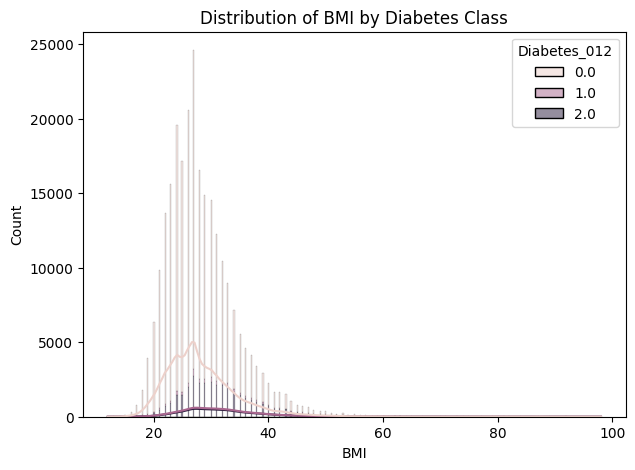

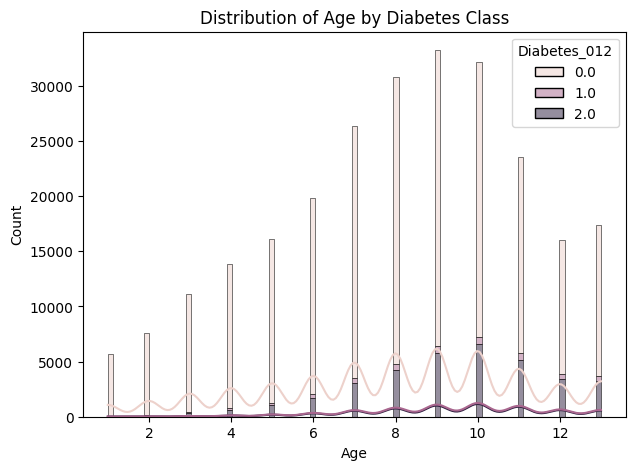

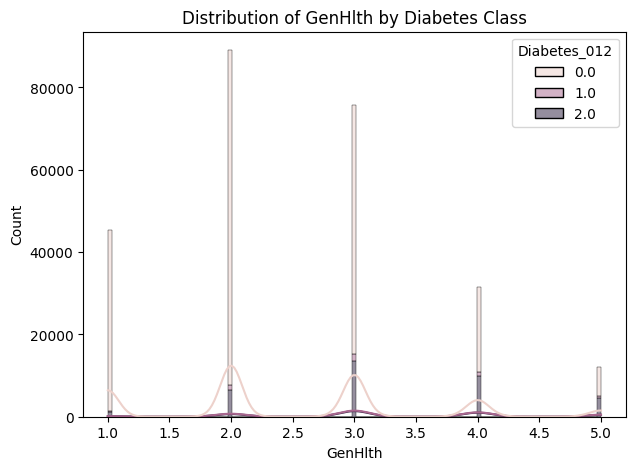

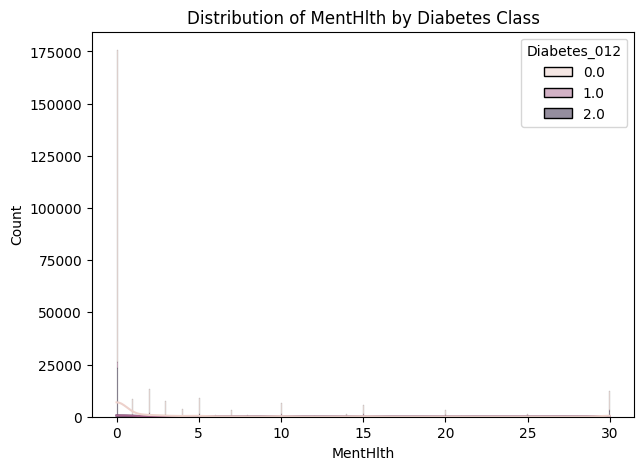

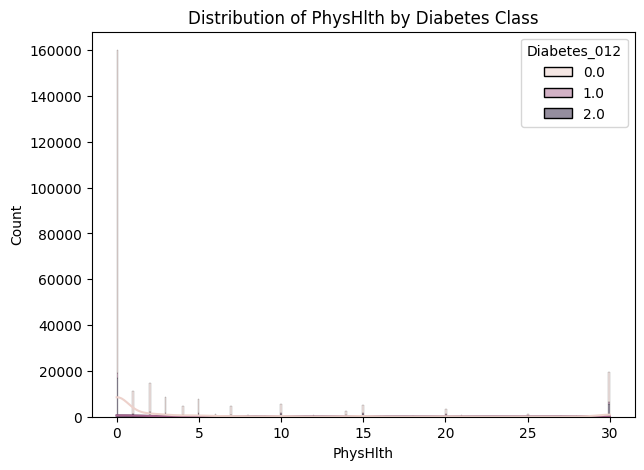

In [ ]:
#For numerical/ordinal variables:
features_to_plot = ['BMI', 'Age', 'GenHlth', 'MentHlth', 'PhysHlth']

for feature in features_to_plot:
    plt.figure(figsize=(7,5))
    sns.histplot(data=df_multi, x=feature, hue='Diabetes_012', kde=True, multiple='stack')
    plt.title(f"Distribution of {feature} by Diabetes Class")
    plt.xlabel(feature)
    plt.ylabel("Count")
    # Save with a unique filename for each feature
    plt.savefig(f'/content/drive/MyDrive/MRP/codes/EDA/Feature_Distribution_{feature}.png', bbox_inches='tight')

    plt.show()

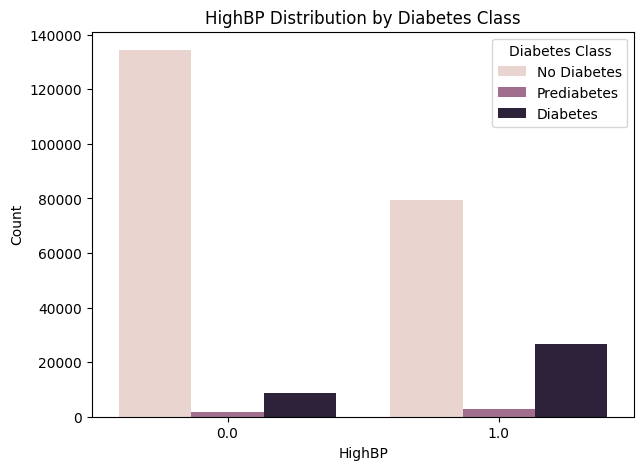

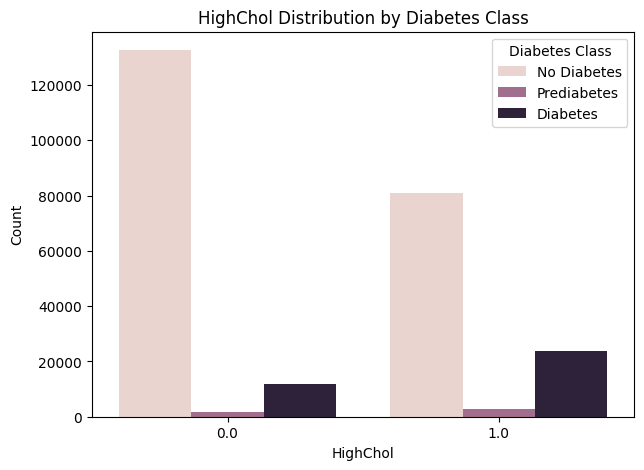

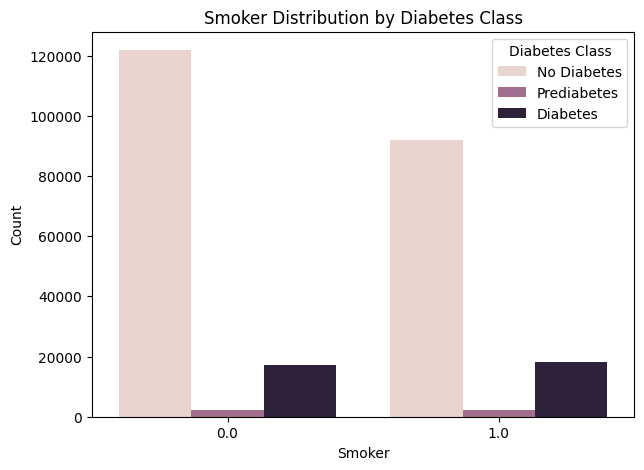

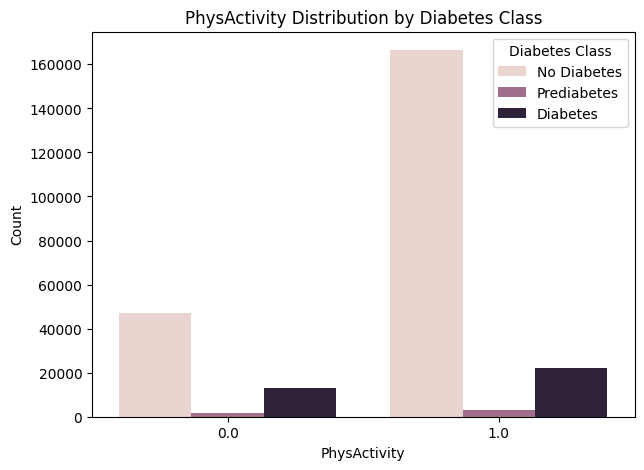

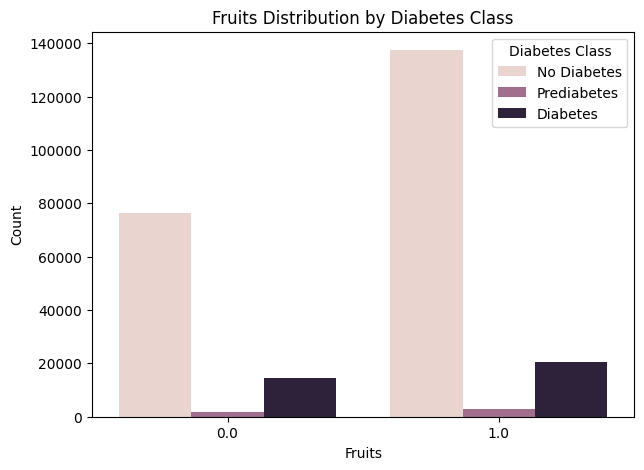

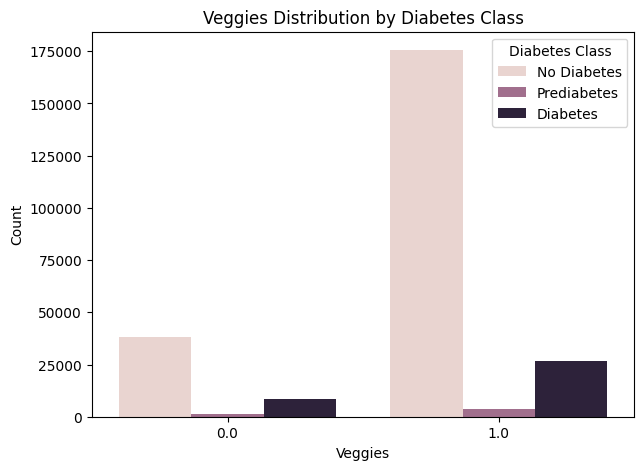

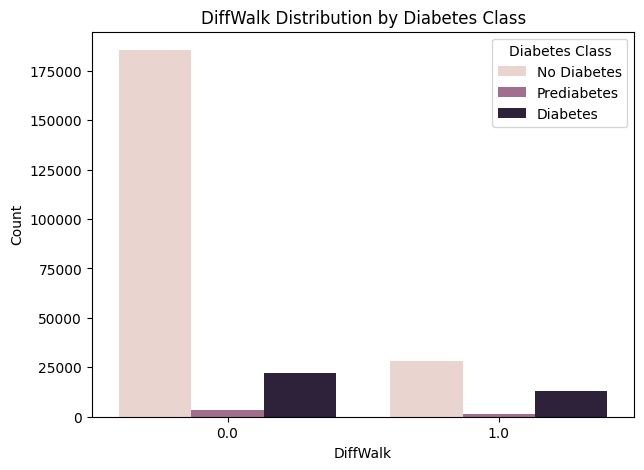

In [ ]:
#binary health indicators:

binary_features = ['HighBP', 'HighChol', 'Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'DiffWalk']

for feature in binary_features:
    plt.figure(figsize=(7,5))
    sns.countplot(data=df_multi, x=feature, hue='Diabetes_012')
    plt.title(f"{feature} Distribution by Diabetes Class")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.legend(title="Diabetes Class", labels=["No Diabetes", "Prediabetes", "Diabetes"])
    plt.savefig(f'/content/drive/MyDrive/MRP/codes/EDA/Feature_Distribution_{feature}.png', bbox_inches='tight')

    plt.show()

#Compare Features Across Diabetes Classes

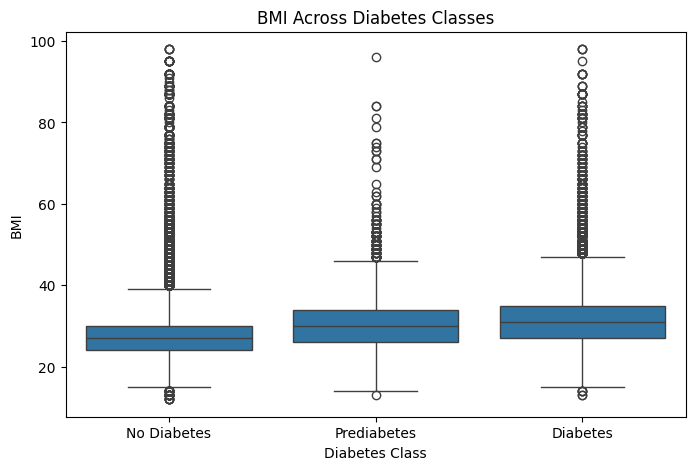

In [ ]:
#RQ3,  to show why multiclass prediction is difficult.

# boxplots:

plt.figure(figsize=(8,5))
sns.boxplot(data=df_multi, x='Diabetes_012', y='BMI')
plt.title("BMI Across Diabetes Classes")
plt.xlabel("Diabetes Class")
plt.ylabel("BMI")
plt.xticks([0, 1, 2], ["No Diabetes", "Prediabetes", "Diabetes"])
plt.savefig('/content/drive/MyDrive/MRP/codes/EDA/BMI_VS_DIABETES.png', bbox_inches='tight')
plt.show()

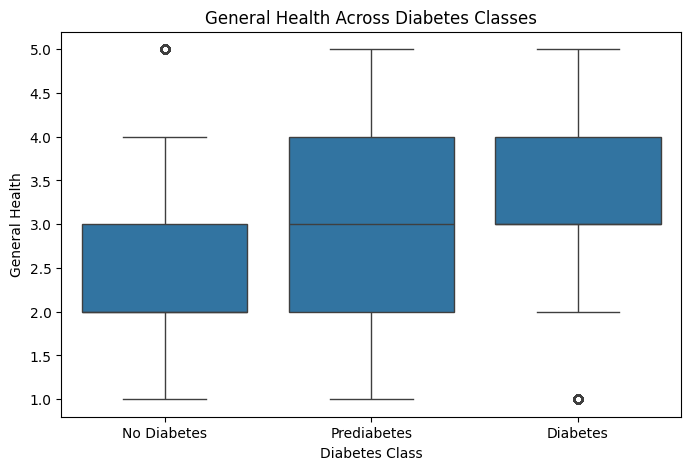

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_multi, x='Diabetes_012', y='GenHlth')
plt.title("General Health Across Diabetes Classes")
plt.xlabel("Diabetes Class")
plt.ylabel("General Health")
plt.xticks([0, 1, 2], ["No Diabetes", "Prediabetes", "Diabetes"])
plt.savefig('/content/drive/MyDrive/MRP/codes/EDA/GEN_HEALTH_VS_DIABETES.png', bbox_inches='tight')
plt.show()

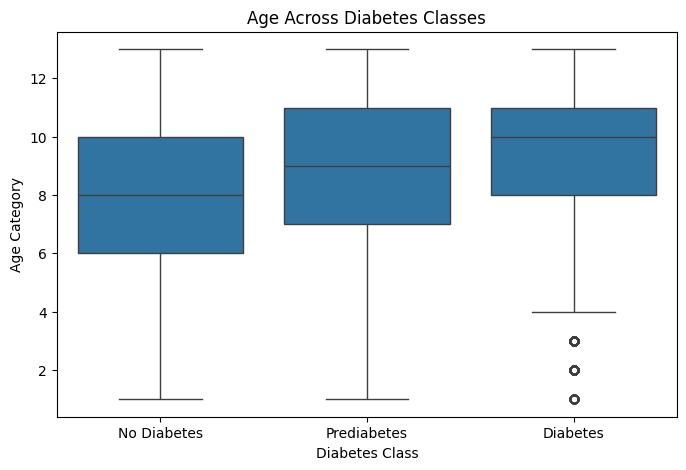

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_multi, x='Diabetes_012', y='Age')
plt.title("Age Across Diabetes Classes")
plt.xlabel("Diabetes Class")
plt.ylabel("Age Category")
plt.xticks([0, 1, 2], ["No Diabetes", "Prediabetes", "Diabetes"])
plt.savefig('/content/drive/MyDrive/MRP/codes/EDA/AGE_VS_DIABETES.png', bbox_inches='tight')
plt.show()

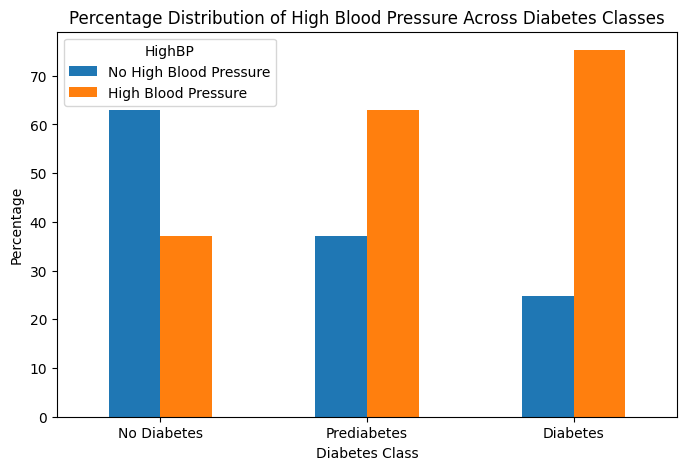

In [ ]:
highbp_prop = pd.crosstab(
    df_multi['Diabetes_012'],
    df_multi['HighBP'],
    normalize='index'
) * 100

highbp_prop.index = ['No Diabetes', 'Prediabetes', 'Diabetes']
highbp_prop.columns = ['No High Blood Pressure', 'High Blood Pressure']

ax = highbp_prop.plot(kind='bar', figsize=(8,5))

plt.title("Percentage Distribution of High Blood Pressure Across Diabetes Classes")
plt.xlabel("Diabetes Class")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="HighBP")
plt.savefig('/content/drive/MyDrive/MRP/codes/EDA/HIGHBP.png', bbox_inches='tight')
plt.show()

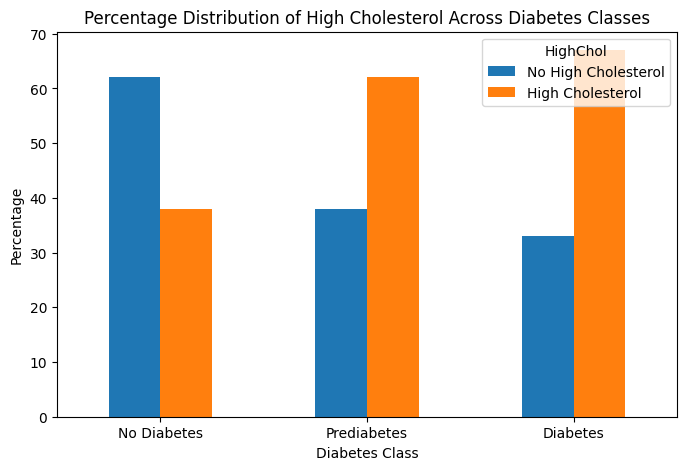

In [ ]:
highchol_prop = pd.crosstab(
    df_multi['Diabetes_012'],
    df_multi['HighChol'],
    normalize='index'
) * 100

highchol_prop.index = ['No Diabetes', 'Prediabetes', 'Diabetes']
highchol_prop.columns = ['No High Cholesterol', 'High Cholesterol']

ax = highchol_prop.plot(kind='bar', figsize=(8,5))

plt.title("Percentage Distribution of High Cholesterol Across Diabetes Classes")
plt.xlabel("Diabetes Class")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="HighChol")
plt.savefig('/content/drive/MyDrive/MRP/codes/EDA/HIGHCHOL.png', bbox_inches='tight')
plt.show()

# Correlation Heatmap

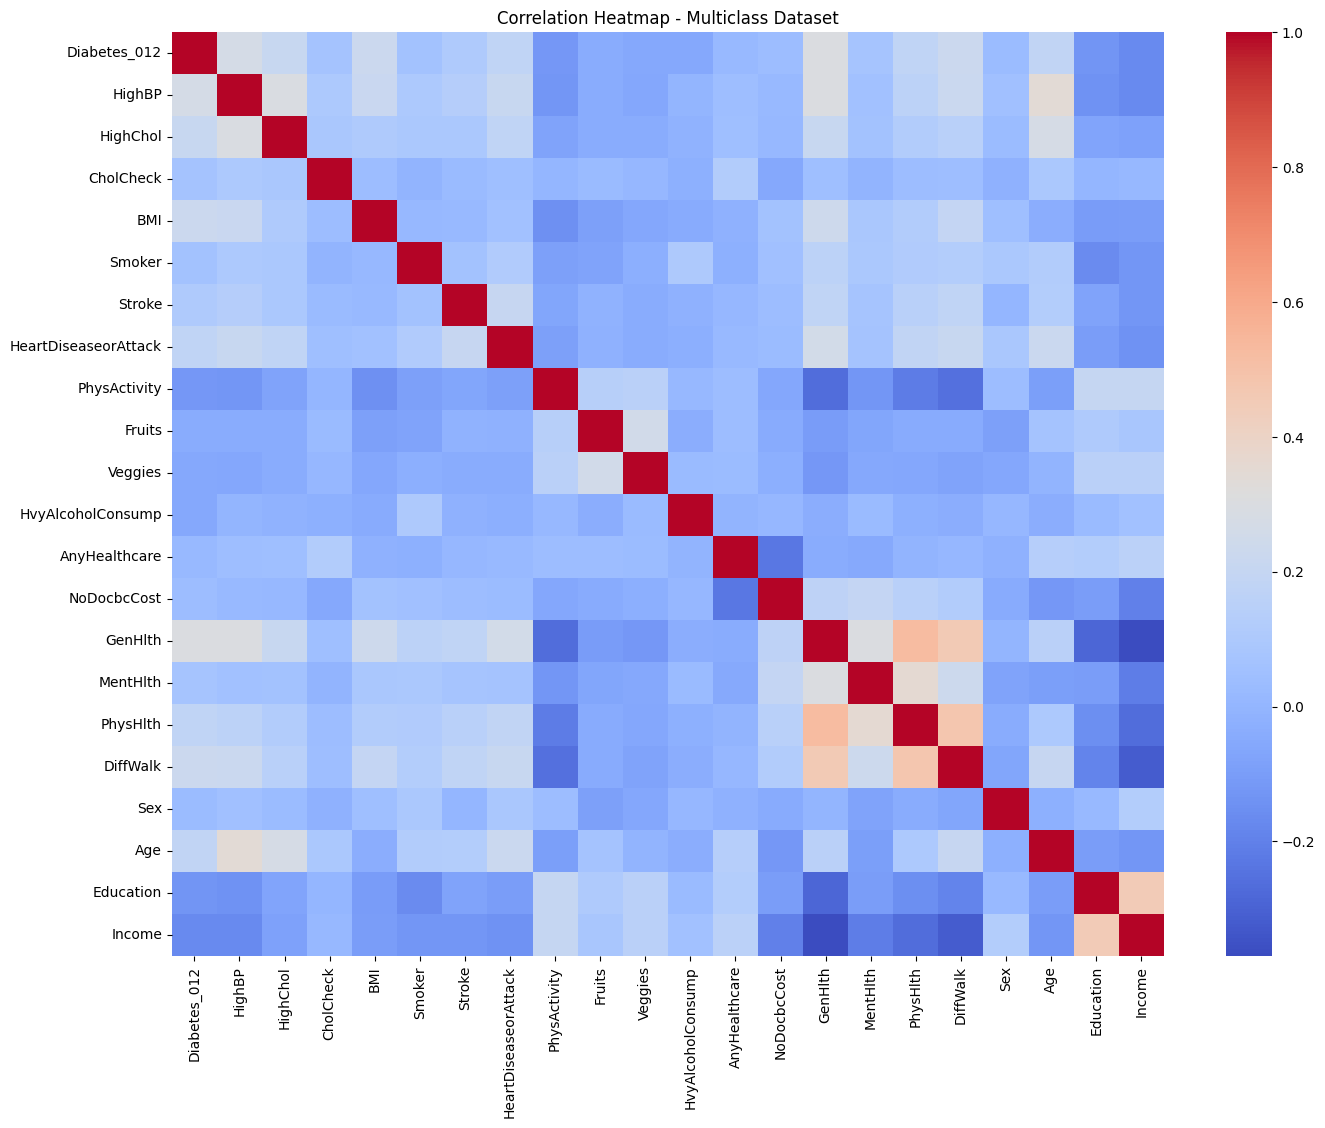

In [3]:
plt.figure(figsize=(16,12))
corr = df_multi.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap - Multiclass Dataset")
plt.savefig('/content/drive/MyDrive/MRP/codes/EDA/correlation.png', bbox_inches='tight')
plt.show()

In [4]:
target_corr = df_multi.corr()['Diabetes_012'].sort_values(ascending=False)
target_corr

,Diabetes_012
Diabetes_012,1.000000
GenHlth,0.302587
HighBP,0.271596
BMI,0.224379
DiffWalk,0.224239
HighChol,0.209085
Age,0.185026
HeartDiseaseorAttack,0.180272
PhysHlth,0.176287
Stroke,0.107179


In [5]:
binary_target_corr = df_binary.corr()['Diabetes_binary'].sort_values(ascending=False)
binary_target_corr

,Diabetes_binary
Diabetes_binary,1.000000
GenHlth,0.293569
HighBP,0.263129
DiffWalk,0.218344
BMI,0.216843
HighChol,0.200276
Age,0.177442
HeartDiseaseorAttack,0.177282
PhysHlth,0.171337
Stroke,0.105816


# Class Imbalance Ratio

To justify SMOTE or class weights.



In [6]:
print("Multiclass target distribution:")
print(df_multi['Diabetes_012'].value_counts())

print("\nMulticlass target percentage:")
print(df_multi['Diabetes_012'].value_counts(normalize=True) * 100)
print("Binary target distribution:")
print(df_binary['Diabetes_binary'].value_counts())

print("\nBinary target percentage:")
print(df_binary['Diabetes_binary'].value_counts(normalize=True) * 100)

majority_multi = df_multi['Diabetes_012'].value_counts().max()
minority_multi = df_multi['Diabetes_012'].value_counts().min()

print("Multiclass imbalance ratio:", majority_multi / minority_multi)
majority_binary = df_binary['Diabetes_binary'].value_counts().max()
minority_binary = df_binary['Diabetes_binary'].value_counts().min()

print("Binary imbalance ratio:", majority_binary / minority_binary)

Multiclass target distribution:
Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

Multiclass target percentage:
Diabetes_012
0.0    84.241170
2.0    13.933302
1.0     1.825528
Name: proportion, dtype: float64
Binary target distribution:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Binary target percentage:
Diabetes_binary
0.0    86.066698
1.0    13.933302
Name: proportion, dtype: float64
Multiclass imbalance ratio: 46.14618872813647
Binary imbalance ratio: 6.177049736886777


#Preliminary Random Forest Feature Importance



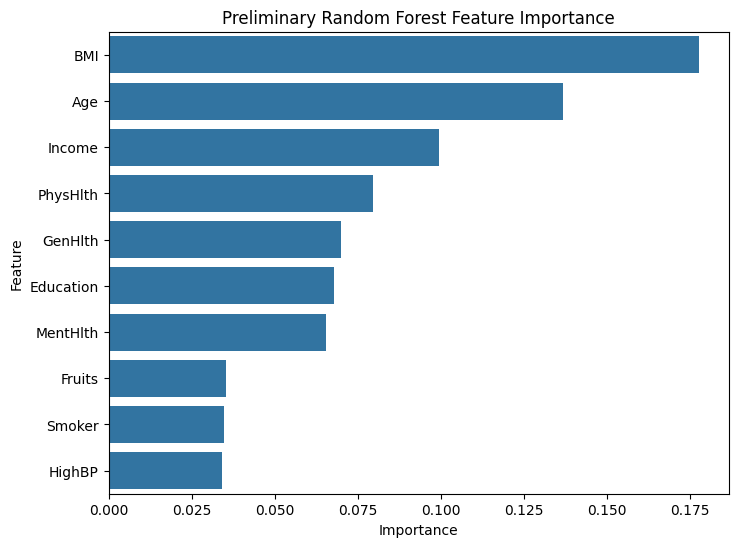

In [7]:
#For multiclass:

X = df_multi.drop('Diabetes_012', axis=1)
y = df_multi['Diabetes_012']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

#Plot top 10:

plt.figure(figsize=(8,6))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')
plt.title("Preliminary Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig('/content/drive/MyDrive/MRP/codes/EDA/Preliminary Random Forest Feature Importance.png', bbox_inches='tight')
plt.show()